In [1]:
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from tqdm import tqdm

In [2]:
"""REPRODUCABLE"""
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"GPU Memory Reserved:  {torch.cuda.memory_reserved()  / 1024**2:.2f} MB")


Using device: cuda
GPU Memory Allocated: 0.00 MB
GPU Memory Reserved:  0.00 MB


In [6]:
"""Dataset Paths"""
TRAIN_REAL   = "/kaggle/input/anti-spoofing-replay-attack-frames/FULL_DATASET_KAGGLE/FULL_DATASET_FRAMES/train/real"
TRAIN_ATTACK = "/kaggle/input/anti-spoofing-replay-attack-frames/FULL_DATASET_KAGGLE/FULL_DATASET_FRAMES/train/attack"
TEST_REAL    = "/kaggle/input/anti-spoofing-replay-attack-frames/FULL_DATASET_KAGGLE/FULL_DATASET_FRAMES/test/real"
TEST_ATTACK  = "/kaggle/input/anti-spoofing-replay-attack-frames/FULL_DATASET_KAGGLE/FULL_DATASET_FRAMES/test/attack"

CKPT_PATH  = "/kaggle/working/spoofnet.pth"
NUM_EPOCHS = 20

# Dataset class

In [9]:
class AntispoofDataset(Dataset):
    def __init__(self, real_path: str, attack_path: str, transform=None):
        self.samples   = []
        self.transform = transform

        for root_path, label in [(real_path, 1), (attack_path, 0)]:
            for identity in os.listdir(root_path):
                identity_dir = os.path.join(root_path, identity)
                if not os.path.isdir(identity_dir):
                    continue
                for img_name in os.listdir(identity_dir):
                    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append((os.path.join(identity_dir, img_name), label))

        real_count   = sum(1 for _, l in self.samples if l == 1)
        attack_count = sum(1 for _, l in self.samples if l == 0)
        print(f"Loaded {len(self.samples)} samples — Real: {real_count} | Attack: {attack_count}")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

# Augmentation

In [10]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.3),
    transforms.ToTensor(),
    transforms.RandomApply(
        [transforms.Lambda(lambda x: (x + 0.01 * torch.randn_like(x)).clamp(0, 1))], p=0.3
    ),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Loaders

In [11]:
train_dataset = AntispoofDataset(TRAIN_REAL, TRAIN_ATTACK, train_transform)
test_dataset  = AntispoofDataset(TEST_REAL,  TEST_ATTACK,  test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

Loaded 2575 samples — Real: 1216 | Attack: 1359
Loaded 1302 samples — Real: 637 | Attack: 665


# Depthwise block

In [12]:
class DepthwiseBlock(nn.Module):
    """Depthwise-separable residual block with correct BN/ReLU placement."""
    def __init__(self, ch: int):
        super().__init__()
        self.block = nn.Sequential(
            # Depthwise
            nn.Conv2d(ch, ch, 3, padding=1, groups=ch, bias=False),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
            # Pointwise
            nn.Conv2d(ch, ch, 1, bias=False),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.block(x)


# SpoofNet

In [14]:
class SpoofNet(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = timm.create_model(
            "mobilenetv3_small_100",
            pretrained=True,
            features_only=True,
        )
        self.backbone = backbone

        feature_info   = backbone.feature_info
        mid_channels   = feature_info[2]["num_chs"]
        final_channels = feature_info[-1]["num_chs"]

        self.texture_branch = nn.Sequential(
            nn.Conv2d(mid_channels, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            DepthwiseBlock(64),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(final_channels + 64, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)

        texture_feat = self.texture_branch(features[2])

        main_feat = self.global_pool(features[-1])
        main_feat = main_feat.view(main_feat.size(0), -1)

        return self.classifier(torch.cat([main_feat, texture_feat], dim=1))

# Training setup

In [15]:
model     = SpoofNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

best_acc = 0.0
history  = {"train_acc": [], "val_acc": [], "val_auc": [], "train_loss": []}


model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


# Training Loop

In [16]:
def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    tag = "train" if training else "eval "

    with ctx:
        for images, labels in tqdm(loader, desc=f"  [{tag}]", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).squeeze(1)

            if training:
                loss = criterion(outputs, labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * labels.size(0)

            probs    = torch.sigmoid(outputs)
            correct += ((probs > 0.5).float() == labels).sum().item()
            total   += labels.size(0)
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc  = 100.0 * correct / total
    loss = total_loss / total if training else None
    auc  = roc_auc_score(all_labels, all_probs)
    return acc, loss, auc, all_probs, all_labels

In [17]:
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_acc, train_loss, _,   _,     _      = run_epoch(train_loader, training=True)
    val_acc,   _,          auc, probs, labels = run_epoch(test_loader,  training=False)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(auc)
    history["train_loss"].append(train_loss)

    print(f"  Train Acc : {train_acc:.2f}%  |  Loss: {train_loss:.4f}")
    print(f"  Val   Acc : {val_acc:.2f}%    |  AUC:  {auc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  ✓ Best model saved (acc={best_acc:.2f}%)")

    scheduler.step()


Epoch 1/20


  Train Acc : 81.59%  |  Loss: 0.4322
  Val   Acc : 81.18%    |  AUC:  0.9017
  ✓ Best model saved (acc=81.18%)

Epoch 2/20


  Train Acc : 92.58%  |  Loss: 0.1895
  Val   Acc : 86.71%    |  AUC:  0.9629
  ✓ Best model saved (acc=86.71%)

Epoch 3/20


  Train Acc : 95.84%  |  Loss: 0.1139
  Val   Acc : 87.40%    |  AUC:  0.9602
  ✓ Best model saved (acc=87.40%)

Epoch 4/20


  Train Acc : 97.20%  |  Loss: 0.0796
  Val   Acc : 87.63%    |  AUC:  0.9514
  ✓ Best model saved (acc=87.63%)

Epoch 5/20


...

  Train Acc : 99.11%  |  Loss: 0.0248
  Val   Acc : 91.63%    |  AUC:  0.9760

Epoch 17/20


  Train Acc : 99.34%  |  Loss: 0.0203
  Val   Acc : 92.01%    |  AUC:  0.9742

Epoch 18/20


  Train Acc : 99.50%  |  Loss: 0.0151
  Val   Acc : 92.24%    |  AUC:  0.9749

Epoch 19/20


  Train Acc : 99.38%  |  Loss: 0.0157
  Val   Acc : 91.40%    |  AUC:  0.9746

Epoch 20/20


  Train Acc : 99.30%  |  Loss: 0.0182
  Val   Acc : 91.09%    |  AUC:  0.9739


# Plot

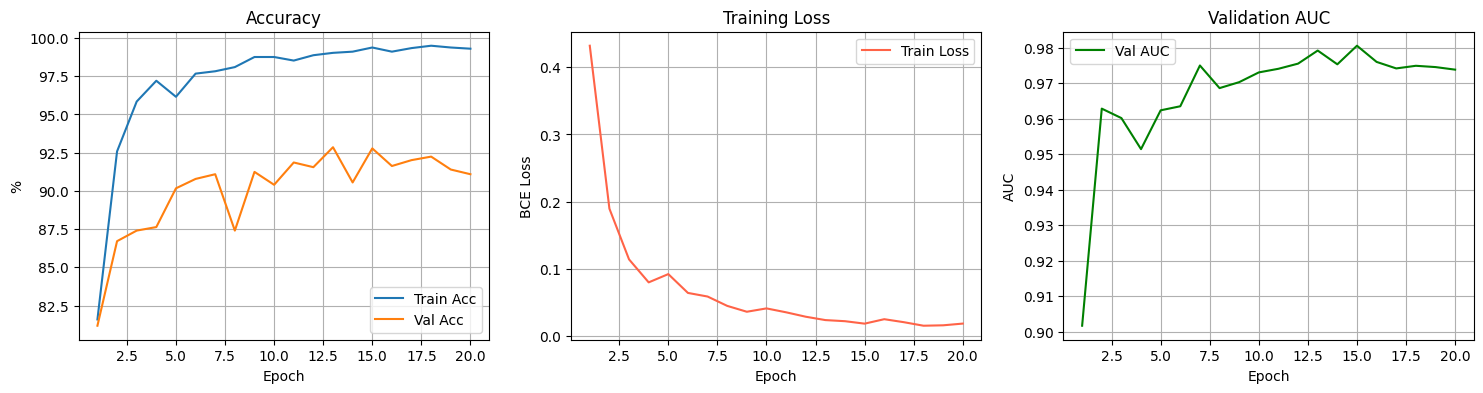

In [25]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history["train_acc"], label="Train Acc")
axes[0].plot(epochs, history["val_acc"],   label="Val Acc")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("%")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["train_loss"], color="tomato", label="Train Loss")
axes[1].set_title("Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BCE Loss")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(epochs, history["val_auc"], color="green", label="Val AUC")
axes[2].set_title("Validation AUC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].legend()
axes[2].grid(True)

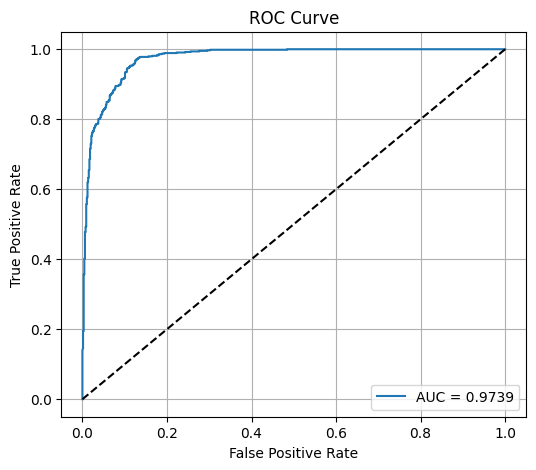

In [26]:
fpr, tpr, _ = roc_curve(labels, probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

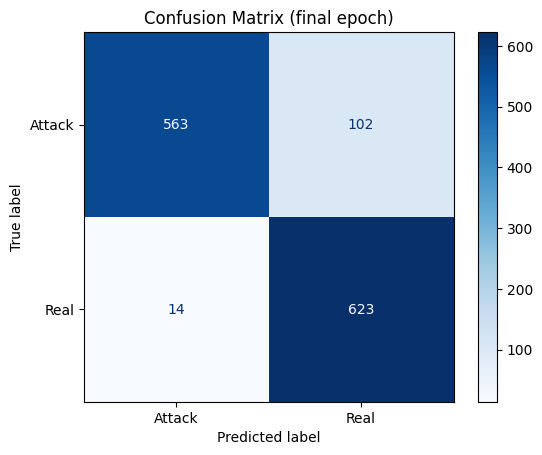

In [27]:
preds_final = (np.array(probs) > 0.5).astype(int)
cm   = confusion_matrix(labels, preds_final)
disp = ConfusionMatrixDisplay(cm, display_labels=["Attack", "Real"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (final epoch)")
plt.show()

# ONNX Export

In [30]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 17.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 15.1 MB/s eta 0:00:00


In [31]:
import onnx

model_export = SpoofNet().to(device)
model_export.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model_export.eval()
print("✓ Best model loaded for export")

dummy_input = torch.randn(1, 3, 224, 224).to(device)
onnx_path   = "spoofnet.onnx"

torch.onnx.export(
    model_export,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes=None,
    external_data=False,
)
print(f"✓ ONNX exported → {onnx_path}")

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


✓ Best model loaded for export


W0225 07:41:37.580000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0225 07:41:37.582000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0225 07:41:37.584000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0225 07:41:37.586000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `SpoofNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SpoofNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 78 of general pattern rewrite rules.
✓ ONNX exported → spoofnet.onnx
